# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Hamsa Saber  
**Student ID:** 1210359

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [3]:
# Write your Data Pipeline code here

# 1. Load the dataset
df = pd.read_csv('kidney_disease.csv')

# 2. Handle messy target values
df['classification']=df['classification'].replace({'ckd\t': '1', 'notckd': 0, 'ckd': 1})
df['classification'] = pd.to_numeric(df['classification'],errors='coerce')

# 2.2. Drop irrelevant columns
df = df.drop('id', axis=1)

# 2.3. drop categorical columns
df_numeric = df.select_dtypes(include=[np.number])

# 3. Handle missing values impute missing values with median for numeric columns
df_numeric = df_numeric.fillna(df_numeric.median())

# 4. Split the dataset into features and target variable
X = df_numeric.drop('classification', axis=1).values
y = df_numeric['classification'].values

# 4.2. Split the dataset into training and testing sets 80/20 split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Scale the features using StandardScaler to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training samples: {X_train_scaled.shape[0]}, Validation samples: {X_val_scaled.shape[0]}")
print(f"Number of features: {X_train_scaled.shape[1]}")

Training samples: 320, Validation samples: 80
Number of features: 11


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

c:\Users\Pavilion\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Trainig Baseline model to overfit
Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - Recall: 0.8550 - loss: 0.3994 - val_Recall: 0.9800 - val_loss: 0.1225
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.9600 - loss: 0.1032 - val_Recall: 0.9800 - val_loss: 0.0429
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.9700 - loss: 0.0662 - val_Recall: 0.9800 - val_loss: 0.0307
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.9750 - loss: 0.0512 - val_Recall: 0.9800 - val_loss: 0.0284
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.9800 - loss: 0.0436 - val_Recall: 0.9800 - val_loss: 0.0288
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.9800 - loss: 0.0390 - val_Recall: 0.9800 - val_loss: 0.0287
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.9850 - loss: 0.0349 - val_Recall: 0.9800 - val_loss: 0.0287
Epoch 8/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.9850 - loss: 0.0311 - val_Recall: 0.9800

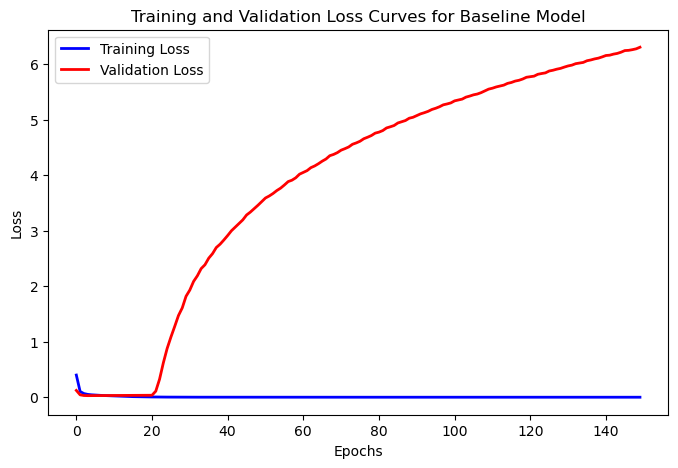

In [5]:
# Write your Baseline Model code here

# Over-parameterised network to force memorisation
baseline_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['Recall'])

print("Trainig Baseline model to overfit")

# Train the model for 150 epochs to ensure overfitting
history_baseline = baseline_model.fit(
    X_train_scaled,y_train,
    epochs=150,
    batch_size=16, #small bacth size helps it memorize faster
    validation_data=(X_val_scaled, y_val),
)

# Plot training and validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history_baseline.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss Curves for Baseline Model')
plt.show()

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

Training Engineered Model
Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - Recall: 0.1950 - loss: 1.3921 - val_Recall: 0.0400 - val_loss: 1.3630
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.2700 - loss: 1.2457 - val_Recall: 0.1400 - val_loss: 1.1570
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Recall: 0.3150 - loss: 1.1122 - val_Recall: 0.4400 - val_loss: 1.0078
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.4900 - loss: 0.9672 - val_Recall: 0.5800 - val_loss: 0.9163
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.4900 - loss: 0.9775 - val_Recall: 0.7400 - val_loss: 0.8271
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.6450 - loss: 0.8508 - val_Recall: 0.8400 - val_loss: 0.7568
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.6900 - loss: 0.8087 - val_Recall: 0.8800 - val_loss: 0.7160
Epoch 8/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.6450 - loss: 0.8063 - val_Recall: 0.9000 - val_lo

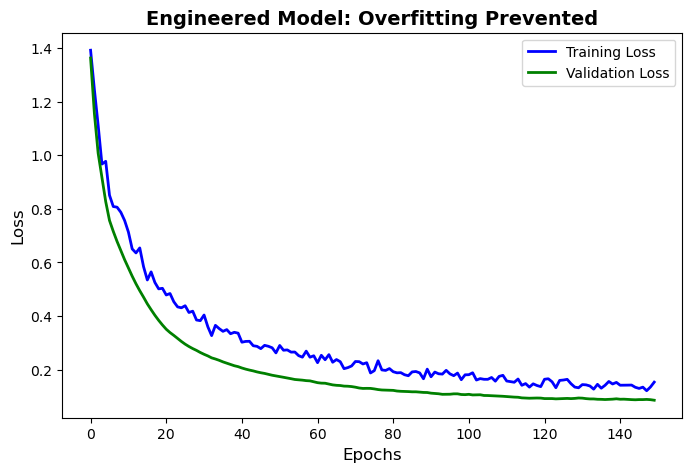

In [8]:
# Write your Engineered Model code here

# Constrained, regularised network
engineered_model = Sequential([
    # Reduced neuron count + L2 weight penalty
    Dense(16, kernel_regularizer=l2(0.01), input_shape=(X_train_scaled.shape[1],)),
    LeakyReLU(alpha=0.1),
    Dropout(0.4), # Randomly turns off 40% of neurons to prevent memorization
    Dense(8, kernel_regularizer=l2(0.01)),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

# Compile optimizing for Recall
engineered_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['Recall'])

# 3. Early stopping when validation loss stops improving
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Training Engineered Model")
history_engineered = engineered_model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping],
)

# 4. Plotting the clinical solution
plt.figure(figsize=(8, 5))
plt.plot(history_engineered.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history_engineered.history['val_loss'], label='Validation Loss', color='green', linewidth=2)

plt.title('Engineered Model: Overfitting Prevented', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.show()

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


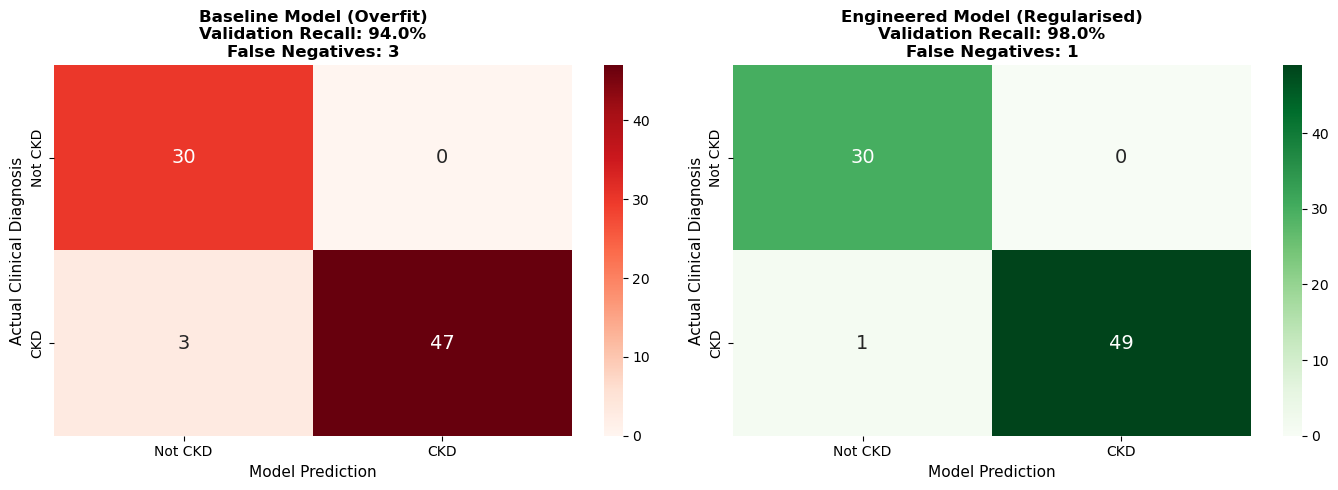

MODEL CAPACITY COMPARISON
Training Samples available: 320
Baseline Parameter Count:   44289 (Massively over-parameterised)
Engineered Parameter Count: 337 (Constrained)


In [10]:
# Write your Evaluation code here

# Generate predictions for both models
y_pred_baseline = (baseline_model.predict(X_val_scaled) > 0.5).astype(int)
y_pred_engineered = (engineered_model.predict(X_val_scaled) > 0.5).astype(int)

# Calculate confusion matrices
cm_baseline = confusion_matrix(y_val, y_pred_baseline)
cm_engineered = confusion_matrix(y_val, y_pred_engineered)

# Calculate validation recall
recall_baseline = recall_score(y_val, y_pred_baseline)
recall_engineered = recall_score(y_val, y_pred_engineered)

# Print results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# baseline model heatmap
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', ax=axes[0], 
            xticklabels=['Not CKD', 'CKD'], yticklabels=['Not CKD', 'CKD'], annot_kws={"size": 14})
axes[0].set_title(f'Baseline Model (Overfit)\nValidation Recall: {recall_baseline*100:.1f}%\nFalse Negatives: {cm_baseline[1,0]}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Clinical Diagnosis', fontsize=11)
axes[0].set_xlabel('Model Prediction', fontsize=11)

# Engineered Model Heatmap
sns.heatmap(cm_engineered, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not CKD', 'CKD'], yticklabels=['Not CKD', 'CKD'], annot_kws={"size": 14})
axes[1].set_title(f'Engineered Model (Regularised)\nValidation Recall: {recall_engineered*100:.1f}%\nFalse Negatives: {cm_engineered[1,0]}', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Clinical Diagnosis', fontsize=11)
axes[1].set_xlabel('Model Prediction', fontsize=11)

plt.tight_layout()
plt.show()

# 5. Print out the mathematical parameter counts
print("="*50)
print("MODEL CAPACITY COMPARISON")
print("="*50)
print(f"Training Samples available: {X_train_scaled.shape[0]}")
print(f"Baseline Parameter Count:   {baseline_model.count_params()} (Massively over-parameterised)")
print(f"Engineered Parameter Count: {engineered_model.count_params()} (Constrained)")

### Mathematical Justification
**Final Parameter Count of Engineered Model:** 337

**Explanation:** By restricting the network's parameters (337) to roughly equal the number of training samples (320), and applying L2 regularisation alongside Dropout to constrain weight magnitudes and prevent neuron co-adaptation, we mathematically restrict the model's degrees of freedom, preventing it from memorising the noise in the small 400-patient dataset and forcing it to learn generalised clinical representations.